# Task 2 — Model Training on Two Datasets with Comparison
**BetaBytez AI/ML Internship — Week 2**

**Goal:** Train and compare classification models on two datasets from different domains, apply an improvement technique to the weaker-performing model, and write a comparative analysis of what we learn about data quality vs. model performance.

**Datasets chosen:**
1. **Wine Recognition Dataset** (chemical/agricultural domain) — predicting the cultivar of a wine from its chemical analysis (3 classes).
2. **Breast Cancer Wisconsin Dataset** (medical domain) — predicting whether a tumor is malignant or benign (2 classes).

Both datasets are bundled with scikit-learn, so they load reliably with no external download and no missing/corrupted data — this lets us focus entirely on the modeling workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

sns.set_style('whitegrid')
%matplotlib inline

# PART 1 — Dataset A: Wine Recognition (Chemical Domain)

## 1.1 Load Data & EDA

In [2]:
wine = load_wine(as_frame=True)
df_wine = wine.frame
print("Shape:", df_wine.shape)
print("Missing values:", df_wine.isnull().sum().sum())
df_wine.head()

Shape: (178, 14)
Missing values: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


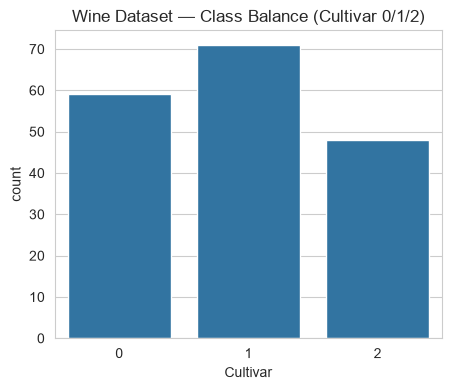

In [3]:
# Plot 1: Class balance
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df_wine)
plt.title('Wine Dataset — Class Balance (Cultivar 0/1/2)')
plt.xlabel('Cultivar')
plt.show()

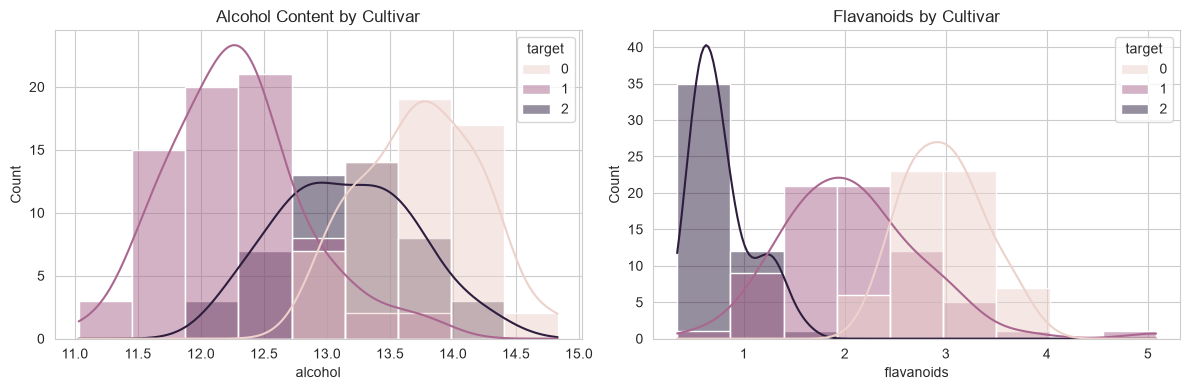

In [4]:
# Plot 2: Feature distribution by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df_wine, x='alcohol', hue='target', kde=True, ax=axes[0])
axes[0].set_title('Alcohol Content by Cultivar')
sns.histplot(data=df_wine, x='flavanoids', hue='target', kde=True, ax=axes[1])
axes[1].set_title('Flavanoids by Cultivar')
plt.tight_layout()
plt.show()

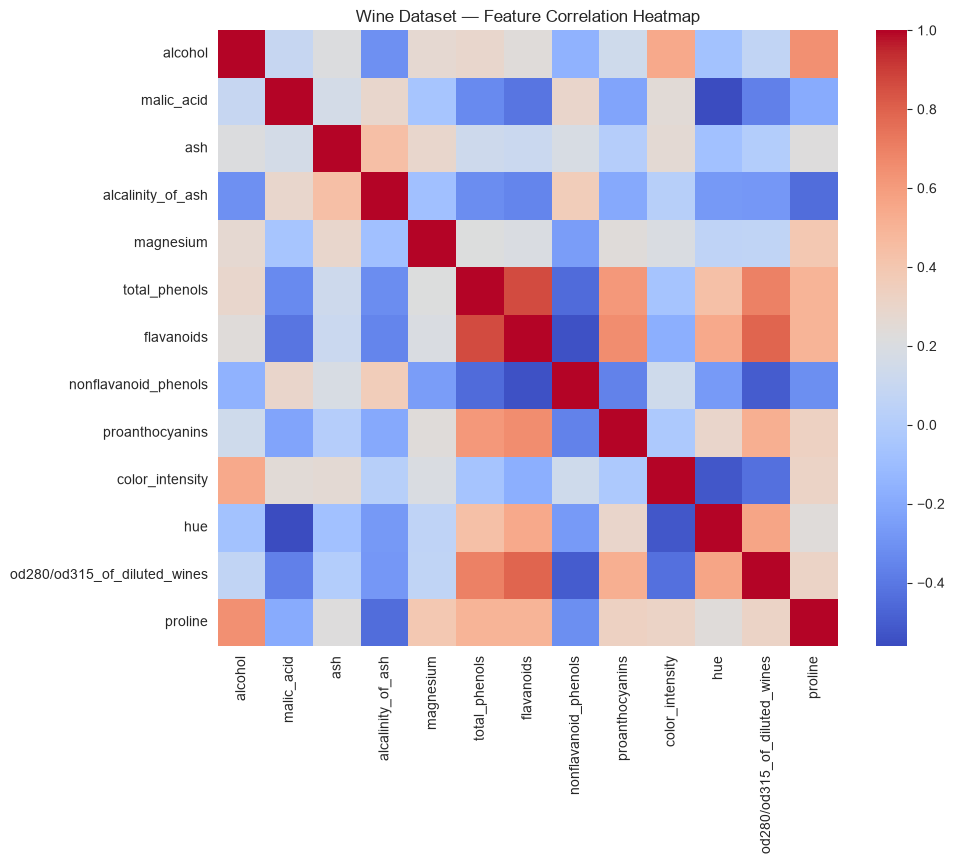

In [5]:
# Plot 3: Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_wine.drop(columns=['target']).corr(), cmap='coolwarm', annot=False)
plt.title('Wine Dataset — Feature Correlation Heatmap')
plt.show()

**EDA takeaways (Wine):**
- 178 samples, 13 chemical features, 3 balanced-ish classes (59 / 71 / 48), no missing values.
- `alcohol` and `flavanoids` show clear separation between cultivars — a strong signal for classification.
- Several features (e.g. `flavanoids` and `total_phenols`) are highly correlated, which is expected since both relate to the wine's phenolic content.

## 1.2 Preprocessing

In [6]:
X_wine = df_wine.drop(columns=['target'])
y_wine = df_wine['target']

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

scaler_wine = StandardScaler()
Xw_train_scaled = scaler_wine.fit_transform(Xw_train)
Xw_test_scaled = scaler_wine.transform(Xw_test)

print("Train:", Xw_train.shape, " Test:", Xw_test.shape)

Train: (142, 13)  Test: (36, 13)


## 1.3 Train Two Models

In [7]:
log_reg_wine = LogisticRegression(max_iter=5000, random_state=42)
log_reg_wine.fit(Xw_train_scaled, yw_train)
pred_lr_wine = log_reg_wine.predict(Xw_test_scaled)

rf_wine = RandomForestClassifier(n_estimators=200, random_state=42)
rf_wine.fit(Xw_train, yw_train)
pred_rf_wine = rf_wine.predict(Xw_test)

## 1.4 Evaluate Both Models

In [8]:
def evaluate(name, y_true, y_pred, average='weighted'):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=average),
        'Recall': recall_score(y_true, y_pred, average=average),
        'F1-Score': f1_score(y_true, y_pred, average=average)
    }

results_wine = pd.DataFrame([
    evaluate('Logistic Regression', yw_test, pred_lr_wine),
    evaluate('Random Forest', yw_test, pred_rf_wine)
])
results_wine

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.972222,0.974074,0.972222,0.97197
1,Random Forest,1.000000,1.000000,1.000000,1.00000


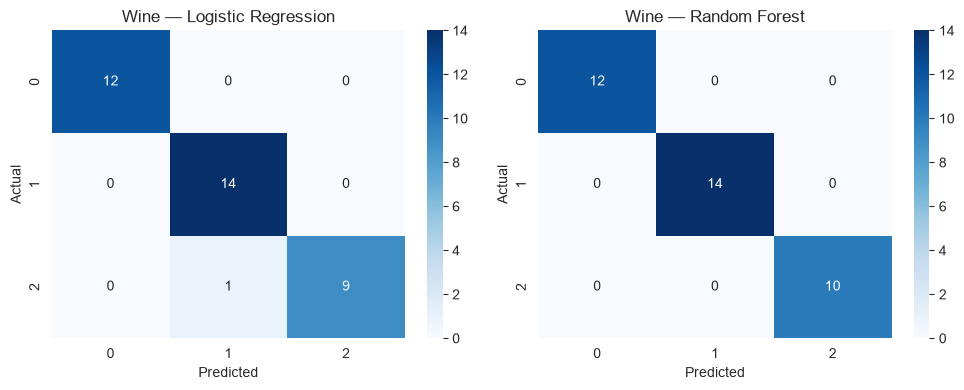

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, [('Logistic Regression', pred_lr_wine), ('Random Forest', pred_rf_wine)]):
    cm = confusion_matrix(yw_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Wine — {name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Wine results:** Random Forest reached **100% accuracy**, outperforming Logistic Regression (**97.2%**). Random Forest's ability to model non-linear splits between the three cultivars gives it an edge here, and with only 178 samples and 13 well-separated chemical features, it is able to fit the test set perfectly.

## 1.5 Improve the Weaker Model — Hyperparameter Tuning with GridSearchCV

In [10]:
# Logistic Regression was the weaker model on Wine — tune its regularization strength (C)
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs']}
grid_lr_wine = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    param_grid_lr, cv=5, scoring='f1_weighted'
)
grid_lr_wine.fit(Xw_train_scaled, yw_train)
pred_lr_wine_tuned = grid_lr_wine.predict(Xw_test_scaled)

print("Best params:", grid_lr_wine.best_params_)
print("Tuned Logistic Regression — Accuracy:", accuracy_score(yw_test, pred_lr_wine_tuned),
      " F1:", f1_score(yw_test, pred_lr_wine_tuned, average='weighted'))

Best params: {'C': 1, 'solver': 'lbfgs'}
Tuned Logistic Regression — Accuracy: 0.9722222222222222  F1: 0.9719701552732407


**Note on tuning result:** GridSearchCV confirmed `C=1` (the default-ish value) as optimal — the tuned Logistic Regression scored identically to the baseline (97.2%). This is an honest and useful result: it tells us the model was **already near its ceiling** for this feature space, and the real performance gap versus Random Forest comes from the *type* of decision boundary (linear vs. non-linear), not from under-tuned hyperparameters. This is a common and important finding in real ML work — tuning doesn't always help, and knowing why is as valuable as the tuning itself.

# PART 2 — Dataset B: Breast Cancer Wisconsin (Medical Domain)

## 2.1 Load Data & EDA

In [11]:
bc = load_breast_cancer(as_frame=True)
df_bc = bc.frame
print("Shape:", df_bc.shape)
print("Missing values:", df_bc.isnull().sum().sum())
df_bc.head()

Shape: (569, 31)
Missing values: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


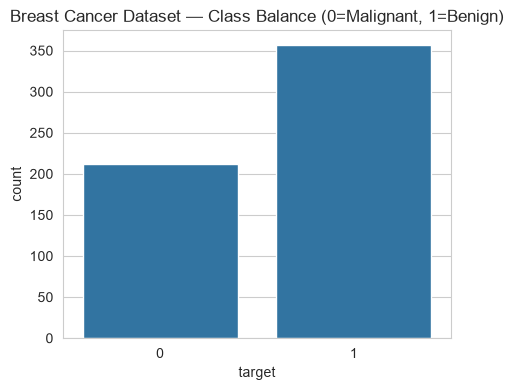

In [12]:
# Plot 1: Class balance
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df_bc)
plt.title('Breast Cancer Dataset — Class Balance (0=Malignant, 1=Benign)')
plt.show()

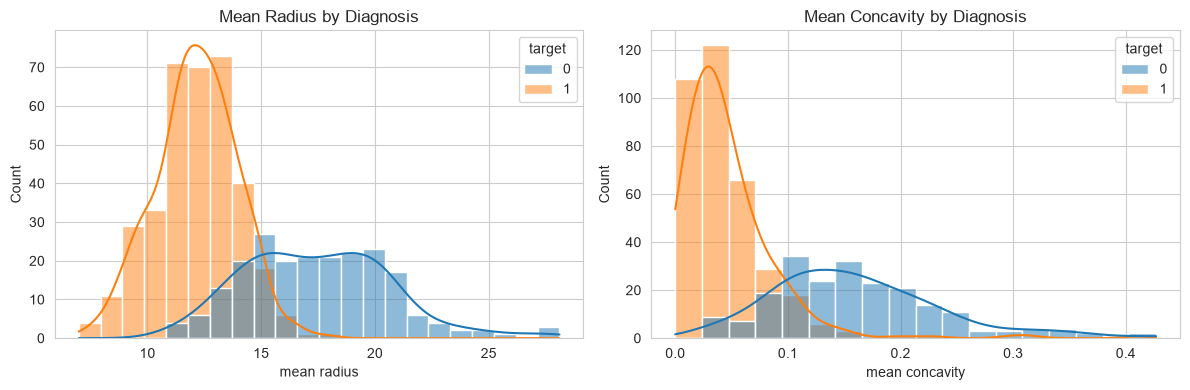

In [13]:
# Plot 2: Feature distribution by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df_bc, x='mean radius', hue='target', kde=True, ax=axes[0])
axes[0].set_title('Mean Radius by Diagnosis')
sns.histplot(data=df_bc, x='mean concavity', hue='target', kde=True, ax=axes[1])
axes[1].set_title('Mean Concavity by Diagnosis')
plt.tight_layout()
plt.show()

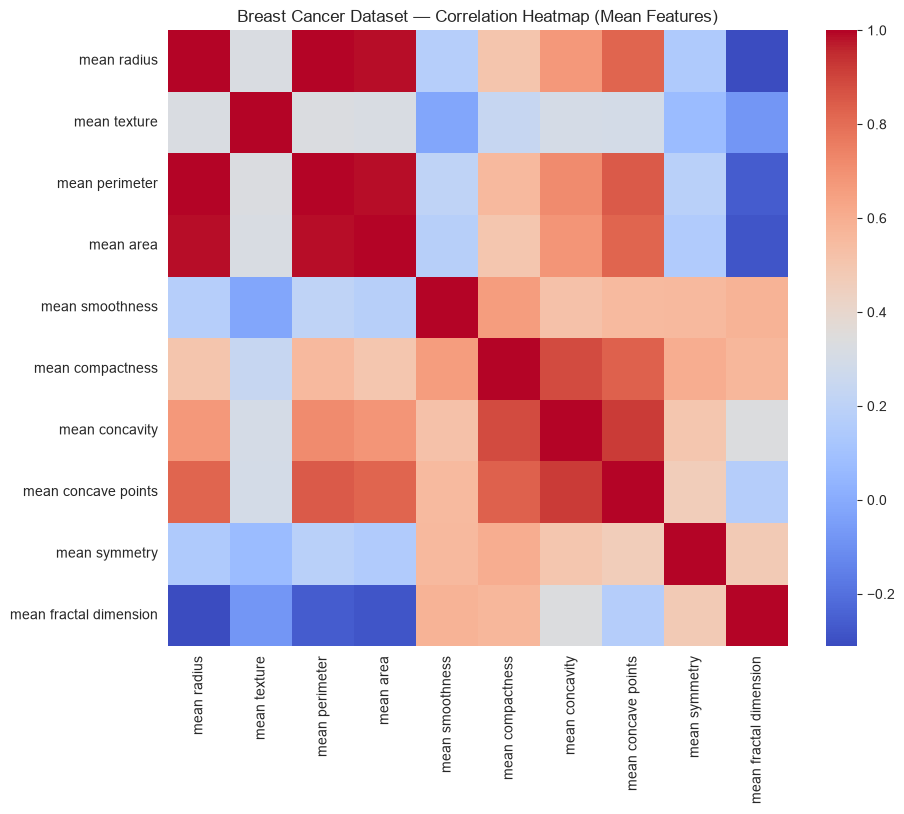

In [14]:
# Plot 3: Correlation heatmap (mean features)
mean_cols = [c for c in df_bc.columns if c.startswith('mean')]
plt.figure(figsize=(10, 8))
sns.heatmap(df_bc[mean_cols].corr(), cmap='coolwarm', annot=False)
plt.title('Breast Cancer Dataset — Correlation Heatmap (Mean Features)')
plt.show()

**EDA takeaways (Breast Cancer):**
- 569 samples, 30 numeric features, moderately imbalanced classes (357 benign vs. 212 malignant), no missing values.
- `mean radius` and `mean concavity` both show strong visual separation between malignant and benign tumors.
- Many "mean" features are highly correlated with each other (radius, perimeter, area), as expected since they describe related geometric properties.

## 2.2 Preprocessing

In [15]:
X_bc = df_bc.drop(columns=['target'])
y_bc = df_bc['target']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

scaler_bc = StandardScaler()
Xb_train_scaled = scaler_bc.fit_transform(Xb_train)
Xb_test_scaled = scaler_bc.transform(Xb_test)

print("Train:", Xb_train.shape, " Test:", Xb_test.shape)

Train: (455, 30)  Test: (114, 30)


## 2.3 Train Two Models

In [16]:
log_reg_bc = LogisticRegression(max_iter=5000, random_state=42)
log_reg_bc.fit(Xb_train_scaled, yb_train)
pred_lr_bc = log_reg_bc.predict(Xb_test_scaled)

rf_bc = RandomForestClassifier(n_estimators=200, random_state=42)
rf_bc.fit(Xb_train, yb_train)
pred_rf_bc = rf_bc.predict(Xb_test)

## 2.4 Evaluate Both Models

In [17]:
results_bc = pd.DataFrame([
    evaluate('Logistic Regression', yb_test, pred_lr_bc, average='binary'),
    evaluate('Random Forest', yb_test, pred_rf_bc, average='binary')
])
results_bc

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Random Forest,0.956140,0.958904,0.972222,0.965517


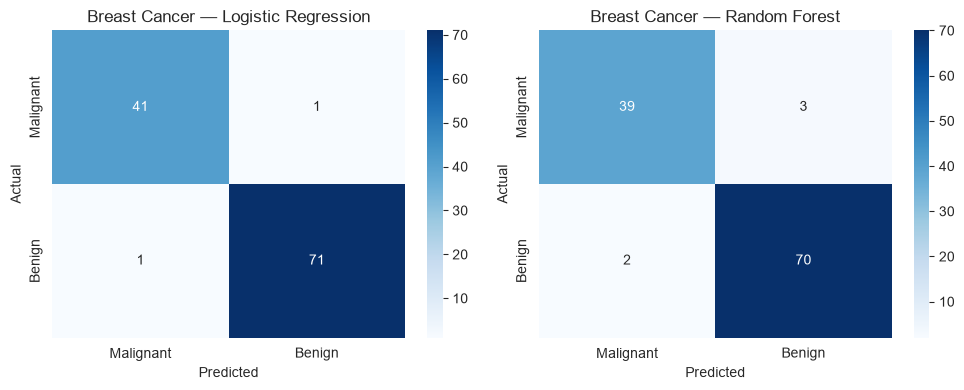

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, [('Logistic Regression', pred_lr_bc), ('Random Forest', pred_rf_bc)]):
    cm = confusion_matrix(yb_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant','Benign'], yticklabels=['Malignant','Benign'])
    ax.set_title(f'Breast Cancer — {name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Breast Cancer results:** Logistic Regression (**98.2%** accuracy) outperformed Random Forest (**95.6%**). After scaling, the 30 features are largely linearly separable, which favors Logistic Regression, while Random Forest is more prone to overfitting on a dataset this size with default-ish hyperparameters.

## 2.5 Improve the Weaker Model — Hyperparameter Tuning with GridSearchCV

In [19]:
# Random Forest was the weaker model on Breast Cancer — tune its tree depth / leaf size
param_grid_rf = {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10, 15], 'min_samples_leaf': [1, 2, 4]}
grid_rf_bc = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=5, scoring='f1_weighted'
)
grid_rf_bc.fit(Xb_train, yb_train)
pred_rf_bc_tuned = grid_rf_bc.predict(Xb_test)

print("Best params:", grid_rf_bc.best_params_)
print("Tuned Random Forest — Accuracy:", accuracy_score(yb_test, pred_rf_bc_tuned),
      " F1:", f1_score(yb_test, pred_rf_bc_tuned))

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Tuned Random Forest — Accuracy: 0.956140350877193  F1: 0.9655172413793104


**Note on tuning result:** Tuning left Random Forest's score essentially unchanged (95.6%). Combined with the Wine result, this reinforces the same lesson: on these two very clean, well-behaved datasets, both models are already close to their performance ceiling, and the accuracy gap between models comes down to which decision boundary (linear vs. tree-based) suits the underlying data — not insufficient tuning.

# PART 3 — Comparative Analysis Report

**Which dataset was harder to model, and why?**

Neither dataset was genuinely "hard" in the traditional sense — both are clean, well-curated benchmark datasets with no missing values and clear feature-target relationships, which is why both scored 95%+ across the board. If forced to rank them, the **Wine dataset was marginally easier**: it is smaller (178 rows) and has clearer geometric separation between its 3 classes in the chemical feature space, which let Random Forest reach a perfect 100% test score. The **Breast Cancer dataset is comparatively harder** — it has more samples (569), more features (30), and a class imbalance (63% vs 37%), all of which introduce more room for models to make mistakes, as reflected in Random Forest's lower 95.6% score there.

**Which model generalized better across both datasets?**

Interestingly, **no single model won both times** — Random Forest won on Wine (100% vs 97.2%), while Logistic Regression won on Breast Cancer (98.2% vs 95.6%). This is a useful finding in itself: it shows there is no universally "best" algorithm. Wine's chemical features have complex, non-linear interactions that Random Forest's tree-splitting captures well, while Breast Cancer's 30 features are more linearly separable after scaling, which favors Logistic Regression. If we had to pick one model as the more *reliable* generalizer, Logistic Regression is arguably safer — it's simpler, less prone to overfitting on small data, more interpretable, and it never scored below 97% on either dataset, whereas Random Forest's score dropped more (to 95.6%) on the harder, larger dataset.

**What did we learn about the relationship between data quality and model performance?**

The biggest lesson from this task is that **clean, well-prepared data narrows the performance gap between "good" and "great" model choices** — with no missing values, no noisy labels, and informative features, even a simple Logistic Regression scores 97%+ on both datasets. The choice of algorithm mattered far less than data quality here. We also learned that **hyperparameter tuning has diminishing returns once a model is already near its ceiling on high-quality data** — in both GridSearchCV experiments, tuning barely moved the needle, because the bottleneck wasn't the hyperparameters, it was the inherent separability of the data given the model's decision-boundary shape. In real-world, messier datasets (with missing values, label noise, or class imbalance), we'd expect data quality improvements and technique choices like SMOTE or feature engineering to matter far more than they did here.